# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

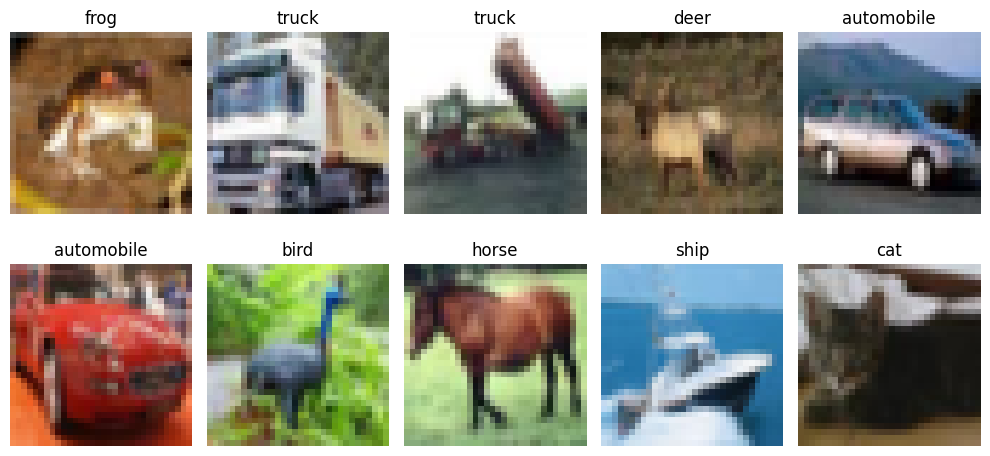

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.2669 - loss: 1.9933 - val_accuracy: 0.3330 - val_loss: 1.8470
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3160 - loss: 1.8665 - val_accuracy: 0.3656 - val_loss: 1.7839
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.3373 - loss: 1.8142 - val_accuracy: 0.3620 - val_loss: 1.7965
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.3443 - loss: 1.7907 - val_accuracy: 0.3766 - val_loss: 1.7425
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3549 - loss: 1.7692 - val_accuracy: 0.3866 - val_loss: 1.7168
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3633 - loss: 1.7520 - val_accuracy: 0.3574 - val_loss: 1.7612
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 34ms/step - accuracy: 0.3687 - loss: 1.7322 - val_accuracy: 0.3964 - val_loss: 1.6999
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3796 - loss: 1.7103 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4205 - loss: 1.6508
ANN Test Accuracy: 0.4205000102519989


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 102s 141ms/step - accuracy: 0.4761 - loss: 1.4751 - val_accuracy: 0.5570 - val_loss: 1.2456
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.6123 - loss: 1.1121 - val_accuracy: 0.5952 - val_loss: 1.1801
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.6776 - loss: 0.9368 - val_accuracy: 0.6714 - val_loss: 0.9339
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 122ms/step - accuracy: 0.7165 - loss: 0.8147 - val_accuracy: 0.6794 - val_loss: 0.9232
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.7486 - loss: 0.7214 - val_accuracy: 0.6952 - val_loss: 0.9081
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 127ms/step - accuracy: 0.7770 - loss: 0.6371 - val_accuracy: 0.6670 - val_loss: 0.9747
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 127ms/step - accuracy: 0.7978 - loss: 0.5718 - val_accuracy: 0.7344 - val_loss: 0.8205
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.8146 - loss

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6955 - loss: 1.0529
CNN Test Accuracy: 0.6955000162124634


## 📈 Compare Learning Curves

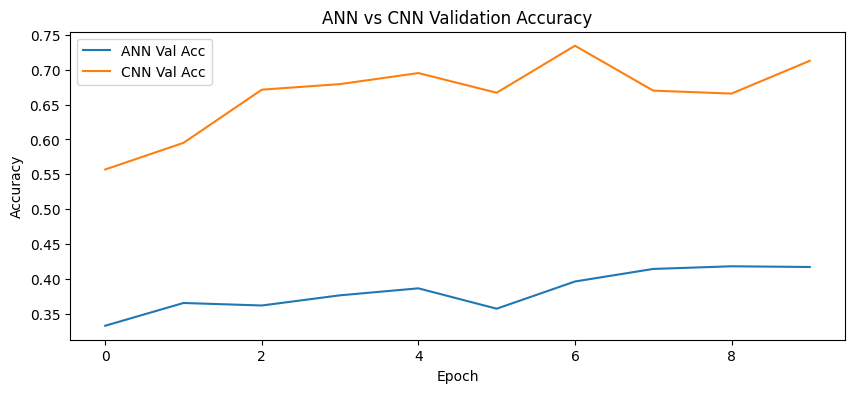

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [10]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [11]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4205
1,CNN,0.6955


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

## My Experiments and Comparisons

In [12]:
# Increase ANN layers
ann_configs = {
    "2 Hidden Layers": [512,256],
    "3 Hidden Layers": [512,256,128],
    "4 Hidden Layers": [1024,512,256,128]
}

ann_results = {}
for name, units in ann_configs.items():
    model = tf.keras.Sequential()
    model.add(layers.Input(shape=(3072,)))
    for u in units:
        model.add(layers.Dense(u, activation='relu'))
        model.add(layers.Dropout(0.3))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train_flat, y_train, epochs=10, validation_split=0.2, verbose=0)
    _, acc = model.evaluate(x_test_flat, y_test, verbose=0)
    ann_results[name] = acc

pd.DataFrame(ann_results.items(), columns=['Architecture','Test Accuracy'])

,Architecture,Test Accuracy
0,2 Hidden Layers,0.3441
1,3 Hidden Layers,0.3408
2,4 Hidden Layers,0.2817


In [ ]:
# CNN filters 32,64,128 comparison
filter_configs = [32,64,128]
cnn_results = {}

for f in filter_configs:
    model = models.Sequential([
        layers.Conv2D(f,3,activation='relu',input_shape=(32,32,3)),
        layers.MaxPooling2D(),
        layers.Conv2D(f*2,3,activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128,activation='relu'),
        layers.Dense(10,activation='softmax')])

    model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    model.fit(x_train_norm,y_train,epochs=10,validation_split=0.2,verbose=0)
    _,acc=model.evaluate(x_test_norm,y_test,verbose=0)
    cnn_results[f'{f} Filters']=acc

pd.DataFrame(cnn_results.items(),columns=['CNN Filters','Test Accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# adding earlystopping and increase epochs to 20
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

aug_model = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.Conv2D(32,3,activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')])

aug_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history_aug = aug_model.fit(x_train_norm,y_train,
                            epochs=20,
                            validation_split=0.2,
                            callbacks=[callback],
                            verbose=1)

_,aug_acc = aug_model.evaluate(x_test_norm,y_test)
print('Augmented CNN Accuracy:',aug_acc)